In [59]:
import torch
import torch.nn as nn

import torch_geometric as tg
import torch_geometric.utils as tgu
import torch_geometric.nn as tgnn
import matplotlib.pyplot as plt

import numpy as np

In [60]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

## Notes from graphcast
 - there are multiple layers of nodes -> some nodes propagate information to more distant nodes
 - loss function takes into account multiple factors - e.g. sample density
 - autoregressive training 
   - model is trained using fix interval
   - to predict more distant (in time) points then previous prediction of a model is used
   - predicting 10 day ahead tends to have large overfitting
 - gnn was selected because weather function is the same in every place of the globe

In [61]:
omega = 1.8

feature_vec_len = 32
x = np.arange(0,6.4,0.1).reshape((-1,1))
t = np.arange(0,6,0.1).reshape([-1,1])

values = np.sin(omega*t+x.T)

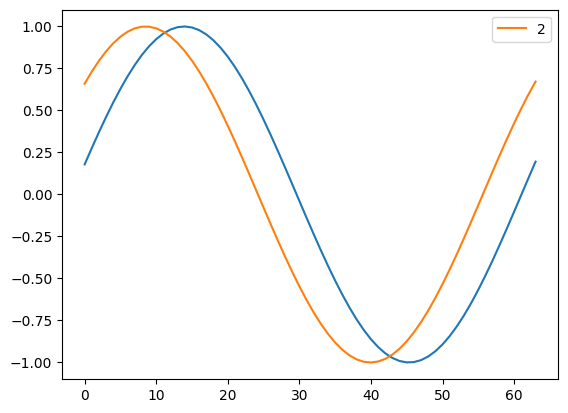

In [62]:
plt.plot(values[1,:])
plt.plot(values[4,:], label='2')
plt.legend()

In [63]:
def get_sample(values, dt=4, inclusion_prob=0.5):
    time_horizon, positions = values.shape

    fully_connected_adj = torch.ones(positions, positions)
    fully_connected = tgu.dense_to_sparse(fully_connected_adj)[0]

    sample = []
    sample_dt = []

    time_stamp = np.random.randint(dt, time_horizon - 2*dt)
    time_to_predict = time_stamp + np.random.randint(1, 2*dt)

    is_included = np.random.random(positions) < inclusion_prob
    for idx, included in zip(range(positions), is_included):
        _time = time_stamp + np.random.randint(-dt, dt)
        sample.append((
            idx/positions,
            included*1.0,
            values[_time, idx] * included,
            _time/64,
            time_to_predict/64,
        ))
        sample_dt.append((
            idx/positions,
            1.0,
            values[time_to_predict, idx],
            time_to_predict/64,
            time_to_predict/64,
        ))

    return tg.data.Data(
        x=torch.tensor(sample, dtype=torch.float32, requires_grad=False),
        edge_index=torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),
        y=torch.tensor(sample_dt, dtype=torch.float32, requires_grad=False)
    )

In [64]:
class feature_encoder(nn.Module):
    def __init__(self, dims=None, output_feature_num=feature_vec_len):
        nn.Module.__init__(self)

        if dims is None:
            self.dims = {
                "time": 1,
                "x_pos": 1,
                "value": 1,
            } 
        else:
            self.dims = dims

        self.input_dimensionality = sum(self.dims.values())

        self.seq = nn.Sequential(
            nn.Linear(self.input_dimensionality, 32),
            nn.GELU(),
            nn.Linear(32, output_feature_num),
            nn.GELU(),
        )

    def forward(self, x):
        return self.seq(x)

In [65]:
fe_model = feature_encoder(dims = {
                "x_pos": 1,
                "value": 1,
                "certaininty": 1,
                "time":1,
                "prediction":1
            } )
te = feature_encoder({'time': 1}, output_feature_num=16)
sample = get_sample(values)
fe_model(sample.x)

/tmp/ipykernel_82/3857665964.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index=torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


tensor([[ 0.0426,  0.0556,  0.0763,  ..., -0.0777,  0.0935,  0.0263],
        [ 0.0538,  0.0107,  0.0252,  ..., -0.0806,  0.0612,  0.0534],
        [ 0.0479,  0.0546,  0.0753,  ..., -0.0772,  0.0913,  0.0239],
        ...,
        [ 0.0936,  0.0234,  0.0991,  ..., -0.0549,  0.0445, -0.0162],
        [ 0.0952,  0.0230,  0.0996,  ..., -0.0547,  0.0438, -0.0170],
        [ 0.0968,  0.0225,  0.1001,  ..., -0.0545,  0.0431, -0.0178]],
       grad_fn=<GeluBackward0>)

In [66]:
# x_cord, y_cord, time
# time_embed 


class gnn_model(nn.Module):
    def __init__(self):
        nn.Module.__init__(self)
        self.gnn_out_ch = 32
        self.edge_vector_len = feature_vec_len
        edge_params_shape = values.shape[1]**2
        self.fe = feature_encoder(dims={
                "x_pos": 1,
                "value": 1,
                "certaininty": 1,
                "time": 1,
                "prediction_time":1,
            } 
        )
        self.edge_params = nn.Parameter(torch.randn([edge_params_shape, self.edge_vector_len])/20)

        self.l1 = tgnn.GAT(
            in_channels=5,#feature_vec_len,
            hidden_channels=4*feature_vec_len,
            num_layers=3,
            out_channels=self.gnn_out_ch,
            dropout=0.1,
            act='gelu',
            edge_dim=self.edge_vector_len,
            v2=True,
        )
        self.l2 = nn.Linear(self.gnn_out_ch, 2)
        self.bsize_edge_params = torch.cat([self.edge_params]*(2048//64))
        self.training_mode = False
    def forward(self, data):

        nodes = data.x
        edges = data.edge_index
        encoded_features = nodes#self.fe(nodes)
        #print(f'aaaa {encoded_features.shape[0], self.edge_params.shape[0]}')

        # if self.training_mode:
        #     g_output = self.l1(encoded_features, edges)#, edge_attr=self.bsize_edge_params)
        # else:
        g_output = self.l1(encoded_features, edges, edge_attr=torch.cat([self.edge_params]*(encoded_features.shape[0]//64)))

        dense_output = self.l2(g_output)

        return dense_output



In [67]:
model = gnn_model()
model.to(DEVICE)
model(sample.to(DEVICE)).shape

torch.Size([64, 2])

In [68]:
NUM_TR_STEPS = 64
BATCH_SIZE = 32
model.training_mode = True
loss_t_0 = []
loss_t_dt = []
optimizer = torch.optim.AdamW(model.parameters(),lr=2e-3,)
loss_fn = nn.MSELoss()
dl = tg.data.DataLoader([get_sample(values) for _ in range(4096)], batch_size=2)

for i in range(NUM_TR_STEPS):
    for idx, batch in enumerate(dl):
        print(f"IDX: {idx}", end='\r')
        batch = batch.to(DEVICE)
        y_hat = model(batch)

        loss = loss_fn(batch.y[:,-3], y_hat[:,-1])

        # check if this is correct place for zero grad
        optimizer.zero_grad()
        loss.backward()

        optimizer.step()

        if idx%8 == 0:
            l_dt = loss.detach().cpu().item()
            loss_t_dt.append(l_dt)
            print(f"l_dt:{l_dt}")
    if i == 1:
        dl = tg.data.DataLoader([get_sample(values) for _ in range(4096)], batch_size=BATCH_SIZE)
    



/tmp/ipykernel_82/3857665964.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index=torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),
/opt/conda/lib/python3.11/site-packages/torch_geometric/deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


l_dt:0.5162544250488281
l_dt:0.4954281449317932
l_dt:0.49539315700531006
l_dt:0.5018020272254944
l_dt:0.5002400279045105
l_dt:0.5043518543243408
l_dt:0.500994861125946
l_dt:0.5072559714317322
l_dt:0.49853622913360596
l_dt:0.5027117729187012
l_dt:0.505577802658081
l_dt:0.4998076856136322
l_dt:0.4952220320701599
l_dt:0.5011224150657654
l_dt:0.502421498298645
l_dt:0.4944953918457031
l_dt:0.492855966091156
l_dt:0.50242680311203
l_dt:0.4954114258289337
l_dt:0.506720244884491
l_dt:0.49827253818511963
l_dt:0.49232789874076843
l_dt:0.500236988067627
l_dt:0.4930678606033325
l_dt:0.4978402554988861
l_dt:0.5081064105033875
l_dt:0.5001477003097534
l_dt:0.5028399229049683
l_dt:0.4922404885292053
l_dt:0.5014721751213074
l_dt:0.49874967336654663
l_dt:0.4952969551086426
l_dt:0.5043200254440308
l_dt:0.49207961559295654
l_dt:0.4999425411224365
l_dt:0.5008842945098877
l_dt:0.5002877116203308
l_dt:0.5044363737106323
l_dt:0.5024774670600891
l_dt:0.4976160526275635
l_dt:0.49998968839645386
l_dt:0.5062904357

In [49]:
torch.mean((
    #y_hat[:,-1:] - sample[2][:,-1:])**2)
    sample[0][:,-1:] - sample[2][:,-1:])**2)

tensor(0.)

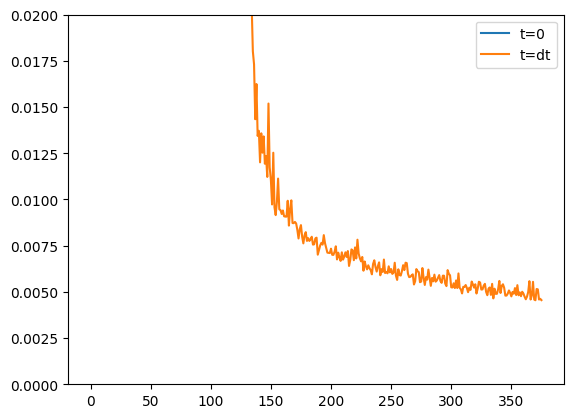

In [70]:
mean_over = 4
t0 = np.array([torch.mean(x).item() for x in loss_t_0])
t0_mean = t0[t0.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

t_dt = np.array(loss_t_dt)
t_dt_mean = t_dt[t_dt.shape[0]%mean_over:].reshape([-1,mean_over]).mean(axis=1)

plt.plot(t0_mean, label='t=0')
plt.plot(t_dt_mean, label='t=dt')
plt.legend()
plt.ylim(0.0,.02)
plt.show()

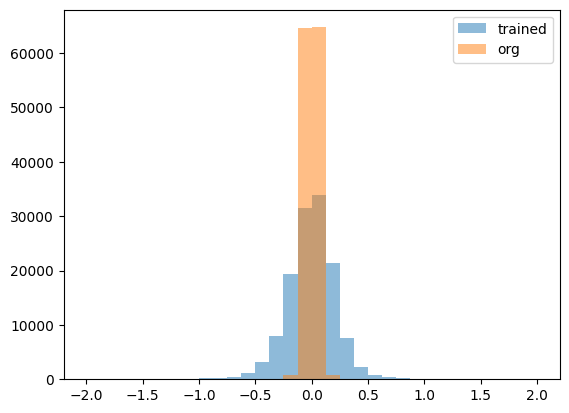

In [71]:
plt.hist(model.edge_params.detach().flatten().cpu(), bins=32, label='trained', alpha=0.5,range=(-2,2))
plt.hist((torch.randn(model.edge_params.shape)/20).flatten(), bins=32, label='org', alpha=0.5,range=(-2,2))
plt.legend()
plt.show()

/tmp/ipykernel_82/3857665964.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index=torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


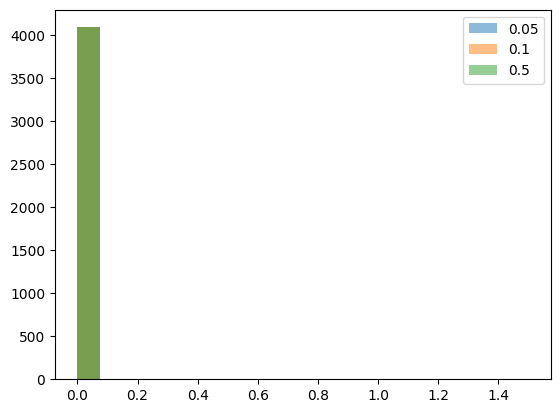

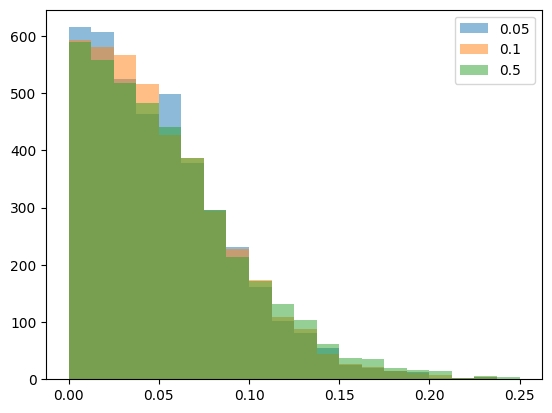

In [75]:
NUM_TEST_STEPS = 64
res_dict = {}
model.training_mode = False
with torch.no_grad():
    for inc_prob in [.05,.1,.5]:
        loss_te_dt = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(values,inclusion_prob=inc_prob).to(DEVICE)

            y_hat = model(
                sample
            )

            l_dt = ((sample.y[:,-3] - y_hat[:,-1])**2).T
            loss_te_dt.append(l_dt.detach())
        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()

for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
plt.legend()
plt.show()

for label, part_res in res_dict.items():
    plt.hist(part_res**0.5,range=(0,.25), alpha=0.5, label=str(label), bins=20)
plt.legend()
plt.show()

/tmp/ipykernel_82/3857665964.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index=torch.tensor(fully_connected, dtype=torch.int64, requires_grad=False),


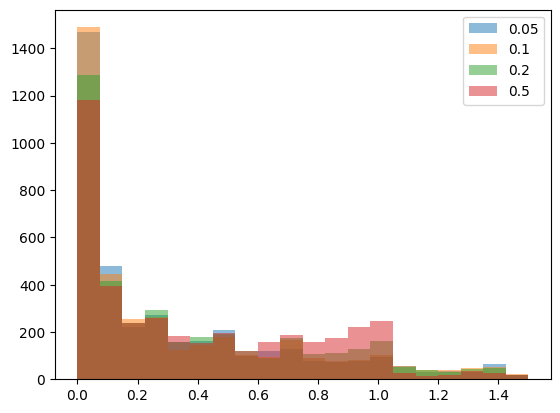

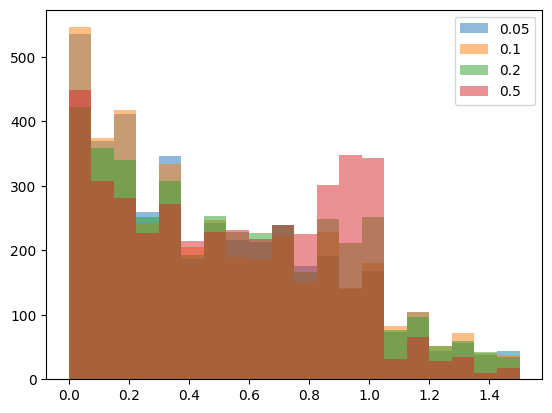

In [73]:
NUM_TEST_STEPS = 64
res_dict = {}

with torch.no_grad():
    for inc_prob in [.05,.1,.2,.5]:
        loss_te_dt = []
        for i in range(NUM_TEST_STEPS):
            sample = get_sample(values,inclusion_prob=inc_prob)

            l_dt = ((sample.y[:,-3] - sample.x[:,-3])**2).T
            loss_te_dt.append(l_dt.detach())
        res_dict[inc_prob] = torch.cat(loss_te_dt).cpu().numpy()

for label, part_res in res_dict.items():
    plt.hist(part_res,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
plt.legend()
plt.show()

for label, part_res in res_dict.items():
    plt.hist(part_res**0.5,range=(0,1.5), alpha=0.5, label=str(label), bins=20)
plt.legend()
plt.show()